## **Allocation of marks**

Stages 1,2,3   Total 30%

Ideally your dataset will not need a lot of work. Marks going for the choosing,  training, evaluation and refining of model primarily




---



Stage 4,5       Total 60%

Choose your model

https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html


Train and evaluate your model. Refine the model or choose another estimator or approach?

Do not overwrite cells and add commentry between iterations.



---




Stage 6         Total 10%

# Stage 1
# Can Steam store features or pre-release features help predict if a game becomes sucessful?

# Describe Data

For this project im using Steam datasets.
the main dataset has store page information like
price, genres, achievements, age rating and platforms.

The second dataset has system requriments.
I wanted to see if store page features and requriments
can help predict if a game becomes sucessful later.

I am not using reviews, playtime or SteamSpy tags as model inputs.
 Reviews and playtime happen after release.# SteamSpy tags can also be made by players after release,


Owners is only used to create the sucess label
It is not used as an input feature input

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score

from google.colab import drive
drive.mount('/content/drive')

# loading datasets
steam_data = pd.read_csv("/content/drive/MyDrive/steam.csv")

steam_reqs = pd.read_csv(
    "/content/drive/MyDrive/steam_requirements_data.csv"
)

steam_data.head()

steam_reqs.head()

# checking columns
steam_data.columns

steam_reqs.columns

# checking missing values
steam_data.isnull().sum()

steam_reqs.isnull().sum()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,0
steam_appid,0
pc_requirements,0
mac_requirements,0
linux_requirements,0
minimum,5
recommended,13185


# Stage 2
# deciding what to predict

I first thought about predicting exact owners,
but owner ranges are very  messy.

so Instead im grouping games into sucess levels.



In [54]:
steam_data["owners"].value_counts().head(20)


def make_sucess(x):

    x = str(x)

    if x == "0-20000":
        return "Low"

    elif x in ["20000-50000", "50000-100000", "100000-200000"]:
        return "Medium"

    else:
        return "High"


steam_data["sucess_level"] = steam_data["owners"].apply(make_sucess)

steam_data["sucess_level"].value_counts()

,count
sucess_level,
Low,18596
Medium,6140
High,2339


# Stage 3
# cleaning and linking the datasets

linking with appid.
I only used appid for joining, not for training.




Rows and columns after merge:
(27075, 25)
Rows after cleaning:
(27075, 20)


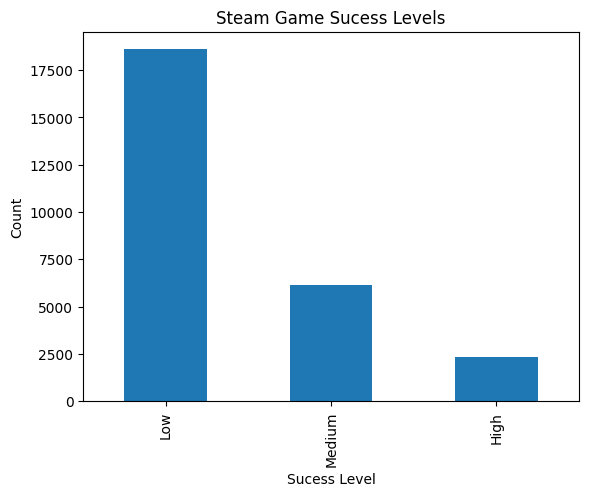

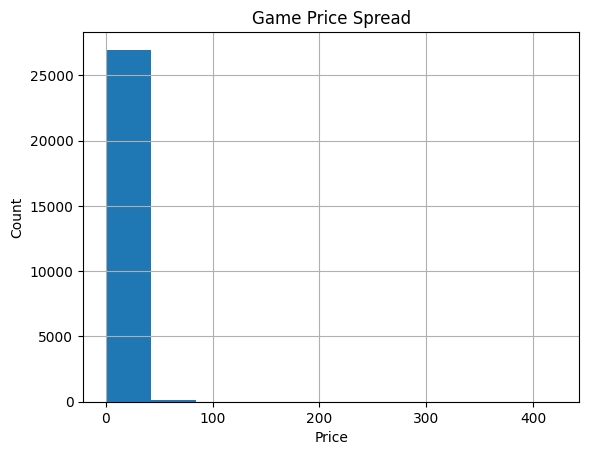

In [55]:
games_df = steam_data.merge(
    steam_reqs,
    left_on="appid",
    right_on="steam_appid",
    how="left"
)

print("Rows and columns after merge:")
print(games_df.shape)

games_df.head()


# making simple platform columns
games_df["windows"] = games_df["platforms"].str.contains(
    "windows",
    case=False,
    na=False
).astype(int)

games_df["mac"] = games_df["platforms"].str.contains(
    "mac",
    case=False,
    na=False
).astype(int)

games_df["linux"] = games_df["platforms"].str.contains(
    "linux",
    case=False,
    na=False
).astype(int)


# simple genre columns from the genre text
# these are store page features, not player success data

games_df["genre_action"] = games_df["genres"].str.contains(
    "Action",
    case=False,
    na=False
).astype(int)

games_df["genre_adventure"] = games_df["genres"].str.contains(
    "Adventure",
    case=False,
    na=False
).astype(int)

games_df["genre_casual"] = games_df["genres"].str.contains(
    "Casual",
    case=False,
    na=False
).astype(int)

games_df["genre_indie"] = games_df["genres"].str.contains(
    "Indie",
    case=False,
    na=False
).astype(int)

games_df["genre_rpg"] = games_df["genres"].str.contains(
    "RPG",
    case=False,
    na=False
).astype(int)

games_df["genre_strategy"] = games_df["genres"].str.contains(
    "Strategy",
    case=False,
    na=False
).astype(int)

games_df["genre_simulation"] = games_df["genres"].str.contains(
    "Simulation",
    case=False,
    na=False
).astype(int)


# simple category columns

games_df["cat_singleplayer"] = games_df["categories"].str.contains(
    "Single-player",
    case=False,
    na=False
).astype(int)

games_df["cat_multiplayer"] = games_df["categories"].str.contains(
    "Multi-player",
    case=False,
    na=False
).astype(int)

games_df["cat_coop"] = games_df["categories"].str.contains(
    "Co-op",
    case=False,
    na=False
).astype(int)


# simple requriment features
# I am not trying to fully parse the text, just basic signals

games_df["has_min_req"] = games_df["minimum"].notna().astype(int)

games_df["mentions_64bit"] = games_df["minimum"].str.contains(
    "64",
    case=False,
    na=False
).astype(int)


game_features = [
    "price",
    "achievements",
    "required_age",
    "english",
    "windows",
    "mac",
    "linux",
    "genre_action",
    "genre_adventure",
    "genre_casual",
    "genre_indie",
    "genre_rpg",
    "genre_strategy",
    "genre_simulation",
    "cat_singleplayer",
    "cat_multiplayer",
    "cat_coop",
    "has_min_req",
    "mentions_64bit"
]


game_data = games_df[
    game_features + ["sucess_level"]
].copy()

game_data = game_data.dropna()

print("Rows after cleaning:")
print(game_data.shape)

game_data.head()


# checking sucess level split
game_data["sucess_level"].value_counts()

game_data["sucess_level"].value_counts().plot(kind="bar")

plt.title("Steam Game Sucess Levels")
plt.xlabel("Sucess Level")
plt.ylabel("Count")

plt.show()


# checking price spread
game_data["price"].hist()

plt.title("Game Price Spread")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

# Stage 4
# train estimator
first trying  logistic regression then Decision Tree
 This model only uses store page features.

In [66]:
# Stage 4
# train estimator

X = game_data[game_features]

y = game_data["sucess_level"]


train_X, val_X, train_y, val_y = train_test_split(
    X,
    y,
    random_state=1,
    test_size=0.25
)


#logistic regression

log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000
    )
)

log_model.fit(train_X, train_y)

log_preds = log_model.predict(val_X)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(val_y, log_preds)
)

print(
    confusion_matrix(val_y, log_preds)
)


# trying Decision Tree after that

game_model = DecisionTreeClassifier(
    random_state=1
)

game_model.fit(train_X, train_y)

game_preds = game_model.predict(val_X)

print(
    "Decision Tree Accuracy:",
    accuracy_score(val_y, game_preds)
)

print(
    confusion_matrix(val_y, game_preds)
)

Logistic Regression Accuracy: 0.7274338897916974
[[ 170  249  190]
 [  27 4327  180]
 [  85 1114  427]]
Decision Tree Accuracy: 0.6850347170926282
[[ 283  157  169]
 [ 143 3724  667]
 [ 214  782  630]]


# Stage 5
trying Random Forest


Random Forest Accuracy: 0.7439799084059684
[[ 260  142  207]
 [  45 4128  361]
 [ 127  851  648]]
Updated Random Forest Accuracy: 0.7596395331659034
[[ 238  150  221]
 [  17 4295  222]
 [  74  943  609]]


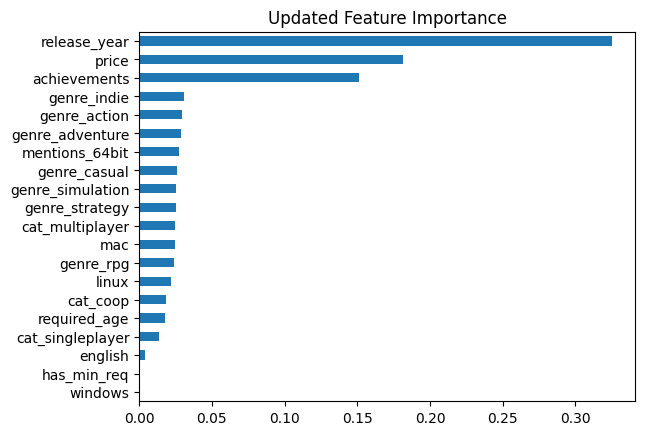

              precision    recall  f1-score   support

        High       0.72      0.39      0.51       609
         Low       0.80      0.95      0.87      4534
      Medium       0.58      0.37      0.45      1626

    accuracy                           0.76      6769
   macro avg       0.70      0.57      0.61      6769
weighted avg       0.74      0.76      0.73      6769



In [68]:
# Stage 5
# trying Random Forest

forest_model = RandomForestClassifier(
    random_state=1,
    n_estimators=100
)

forest_model.fit(train_X, train_y)

forest_preds = forest_model.predict(val_X)

print(
    "Random Forest Accuracy:",
    accuracy_score(val_y, forest_preds)
)

print(
    confusion_matrix(val_y, forest_preds)
)


# refining the model

# adding release year because the Steam market
# has changed alot over time

games_df["release_year"] = pd.to_datetime(
    games_df["release_date"],
    errors="coerce"
).dt.year


# making a new feature list so release_year does not get added twice
better_features = game_features + ["release_year"]

better_features = list(dict.fromkeys(better_features))


# creating updated dataset
game_data_2 = games_df[
    better_features + ["sucess_level"]
].copy()

game_data_2 = game_data_2.dropna()


X = game_data_2[better_features]

y = game_data_2["sucess_level"]


train_X, val_X, train_y, val_y = train_test_split(
    X,
    y,
    random_state=1,
    test_size=0.25
)


# trying a bigger Random Forest
forest_model_2 = RandomForestClassifier(
    random_state=1,
    n_estimators=200,
    max_depth=15
)

forest_model_2.fit(train_X, train_y)

forest_preds_2 = forest_model_2.predict(val_X)

print(
    "Updated Random Forest Accuracy:",
    accuracy_score(val_y, forest_preds_2)
)

print(
    confusion_matrix(val_y, forest_preds_2)
)


# adding release year improved the Random Forest accuracy.
# This probably helped because the Steam market changed alot over time.

importance_scores = pd.Series(
    forest_model_2.feature_importances_,
    index=train_X.columns
)

importance_scores.sort_values().plot(kind="barh")

plt.title("Updated Feature Importance")

plt.show()



print(
    classification_report(
        val_y,
        forest_preds_2
    )
)

# **Stage 6**

# conclusions

 The aim of this project was to see if Steam store
 features could help predict the likely sucess level
 of a game.

At the start I tried different ideas and realised
 some features were too close to already knowing
 if a game was popular or not.

Because of that I removed reviews, playtime and
other popularity related data and focused more on
store page features or pre-release features instead.

Logistic Regression worked alright as a baseline,
 but Random Forest performed better overall.

Adding release year also improved the model a bit.
 This probably helped because the Steam market has
changed alot over time.

 The final model still struggled sometimes between
Medium and High sucess games, but that makes sense
 because game sucess can be very unpredictable.

 Overall I think the final version became realistic
 after removing post-release features

